In [1]:
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import mitsuba as mi
import drjit as dr
import torch
import numpy as np
import time
import math
mi.set_variant('cuda_ad_rgb')


import time
from contextlib import contextmanager

@contextmanager
def timer(name = ""):
    start = time.time()
    try:
        yield
    finally:
        end = time.time()
        print(f"{name} Time elapsed: {end - start:.3f} seconds")

In [2]:
# scene = mi.load_file("assets/sphere_scene.xml", integrator='prb', max_depth=3)
scene = mi.load_file("assets/sphere_scene.xml", integrator='direct')
params = mi.traverse(scene)

In [3]:
# randomly generate some cameras
cameras = []
for _ in range(10):
    x = torch.randn(3)*0.5
    while not 0.4 < x.norm() < 0.7:
        x = torch.randn(3)*0.5
    t = torch.randn(3)*0.3
    while not t.norm() < 0.29:
        t = torch.randn(3)*0.3
    cameras.append({'to_world': mi.Transform4f.look_at(origin=x.numpy(), target=t.numpy(), up=[0, 1, 0]), 'x_fov': 60, 'lightpos':x.numpy()})

# collocated light
def setcamera(params, cam1, update=True):
    params['PerspectiveCamera.x_fov'] = cam1['x_fov']
    params['PerspectiveCamera.to_world'] = cam1['to_world']
    params['PointLight.position'] = cam1['lightpos']
    if update:
        params.update()

In [4]:
# Render ground truth images
GT_imgs = []
for i,cam in enumerate(tqdm(cameras)):
    setcamera(params, cam)
    GT_imgs.append(mi.render(scene, params, spp=32))

  0%|          | 0/10 [00:00<?, ?it/s]

In [5]:
param_keys = ['wood_olive_wood_olive_basecolor.data', 'wood_olive_wood_olive_roughness.data']
tex_shape = params[param_keys[0]].shape[:2]
param_dim = sum([params[key].shape[2] for key in param_keys])

def set_param(params, theta, enable_grad=False):
    assert theta.shape == (*tex_shape, param_dim)
    dim_ptr = 0
    for i, key in enumerate(param_keys):
        curr_dim = params[key].shape[2]
        params[key] = type(params[key])(theta[..., dim_ptr:dim_ptr+curr_dim])
        dim_ptr += curr_dim
        if enable_grad:
            dr.enable_grad(params[key])
    assert dim_ptr == param_dim
    params.update()

In [6]:
import random

def to_tuple(a):
    if isinstance(a, tuple):
        return a
    return (a,)

def prior(x, k=1000, thres=0.04):
    return k*(thres-x).clamp(min=0.0)**2 + k*(x-1+thres).clamp(min=0.0)**2

def dprior(x, k=1000, thres=0.04):
    return 2*k*(x-thres).clamp(max=0.0) + 2*k*(x-1+thres).clamp(min=0.0)

    
def U(theta, camera_ids):
    camera_ids = to_tuple(camera_ids)
    set_param(params, theta)
    # render images and accumulate likelihood to uv-space
    lpdf = 0.0
    for cam_id in camera_ids:
        setcamera(params, cameras[cam_id])
        I = mi.render(scene, params, spp=1, seed=random.randint(0, 2147483647))
        Ierr = I - GT_imgs[cam_id]
        sigma = 0.05
        lpdf += dr.sum(dr.sqr(Ierr) / (2 * sigma**2) + math.log(sigma*math.sqrt(2*math.pi)))
    return lpdf + prior(theta).sum().item()

    
# def U11(theta, camera_ids):
#     camera_ids = to_tuple(camera_ids)
#     set_param(params, theta)
#     # render images and accumulate likelihood to uv-space
#     lpdf = 0.0
#     for cam_id in camera_ids:
#         setcamera(params, cameras[cam_id])
#         I = mi.render(scene, params, spp=4, seed=1)
#         Ierr = I - GT_imgs[cam_id]
#         sigma = 0.05
#         lpdf += dr.sum(dr.sqr(Ierr) / (2 * sigma**2) + math.log(sigma*math.sqrt(2*math.pi)))
#     return lpdf + prior(theta).sum().item()

def dU(theta, camera_ids):
    camera_ids = to_tuple(camera_ids)
    set_param(params, theta, enable_grad=True)
    # render images and accumulate likelihood to uv-space
    lpdf = 0.0
    for cam_id in camera_ids:
        setcamera(params, cameras[cam_id])
        I = mi.render(scene, params, spp=2, seed=random.randint(0, 2147483647))
        dr.backward(dr.sum(dr.sqr(I - GT_imgs[cam_id])))
    param_grad = torch.cat([params[k].grad_().torch() for k in param_keys], axis=-1)
    return param_grad / (2 * 0.05**2) + dprior(theta)

In [7]:
mi.util.convert_to_bitmap(GT_imgs[3])

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [512, 512],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 768 KiB of image data ]
]

In [8]:
for _ in range(16):
    with timer('du'):
        g = dU(torch.rand((*tex_shape, param_dim), device='cuda'), camera_ids=4)

du Time elapsed: 0.777 seconds
du Time elapsed: 0.027 seconds
du Time elapsed: 0.019 seconds
du Time elapsed: 0.015 seconds
du Time elapsed: 0.030 seconds
du Time elapsed: 0.015 seconds
du Time elapsed: 0.030 seconds
du Time elapsed: 0.014 seconds
du Time elapsed: 0.020 seconds
du Time elapsed: 0.030 seconds
du Time elapsed: 0.015 seconds
du Time elapsed: 0.030 seconds
du Time elapsed: 0.015 seconds
du Time elapsed: 0.031 seconds
du Time elapsed: 0.015 seconds
du Time elapsed: 0.029 seconds


In [ ]:
def GD(camera_ids, n_iter=200):
    x = torch.rand((*tex_shape, param_dim), device='cuda')
    g2 = torch.zeros((*tex_shape, param_dim), device='cuda')
    beta = 0.95
    for it in tqdm(range(n_iter)):
        g = dU(x, camera_ids=camera_ids)
        g2 = beta * g2 + (1-beta) * g**2
        # print(x, g)
        x -= 0.01 * g / (1e-6 + g2.sqrt())
        x = x.clamp(min=0, max=1)
    return x

x1 = GD(camera_ids=(3,), n_iter=1000)
plt.figure(figsize=(8,8))
plt.imshow(x1.cpu()[...,0:3]**0.454)

  0%|          | 0/1000 [00:00<?, ?it/s]

2023-09-12 10:38:49 WARN main [BitmapTexture] BitmapTexture: texture named "wood_olive_wood_olive_roughness_midres.png" contains pixels that exceed the [0, 1] range!

2023-09-12 10:38:49 WARN main [BitmapTexture] BitmapTexture: texture named "wood_olive_wood_olive_basecolor_midres.png" contains pixels that exceed the [0, 1] range!

In [10]:
def SVGD(camera_ids, n=20, n_iter=100):
    x = torch.rand((n, *tex_shape, param_dim), device='cuda')
    g2 = torch.zeros_like(x)

    beta = 0.95
    lr = 0.01

    for it in tqdm(range(n_iter)):
        with timer('dU'):
            gradU = torch.stack([dU(xi, camera_ids=camera_ids) for xi in x], dim=0)
        gradx = torch.empty_like(gradU)

        # perform SVGD update row by row (or block of rows) to avoid overflowing memory
        row_block_size = 16
        for r0 in range(0, gradU.shape[1], row_block_size):
            r1 = min(r0+row_block_size, gradU.shape[1])
            # current block of rows: [r0, r1)
        
            pairwise_diff = x[:,r0:r1,...].unsqueeze(1) - x[:,r0:r1,...].unsqueeze(0)
            pairwise_dist2 = torch.sum(pairwise_diff ** 2, dim=-1)
        
            # per-texel bandwidth using median heuristic
            h = torch.quantile(pairwise_dist2.flatten(end_dim=1), q=0.5, dim=0) / math.log(n)
            rbf = torch.exp(-pairwise_dist2 / h)

            gradx[:,r0:r1,...] = 1/n * (torch.einsum('ijab,jabk->iabk', rbf, gradU[:,r0:r1,...]) -2 * (pairwise_diff * rbf.unsqueeze(-1)).sum(axis=1) / h.unsqueeze(-1))
        
        # adagrad
        # avg_gradx = alpha * avg_gradx + (1-alpha) * gradx
        g2 = beta * g2 + (1-beta) * gradx**2
        
        x -= lr * (gradx / (1e-6 + g2.sqrt()))
        x = x.clamp(min=0, max=1)
        # checkpoint
        # if len(x_animation) % 5 == 0:
        #     torch.save(torch.stack(x_animation), "anim1.pt")
    return x

In [12]:
x2 = SVGD((3), n=40, n_iter=200)

  0%|          | 0/200 [00:00<?, ?it/s]

dU Time elapsed: 0.938 seconds
dU Time elapsed: 1.264 seconds
dU Time elapsed: 1.080 seconds
dU Time elapsed: 1.056 seconds
dU Time elapsed: 1.064 seconds
dU Time elapsed: 1.042 seconds
dU Time elapsed: 1.026 seconds
dU Time elapsed: 1.050 seconds
dU Time elapsed: 1.053 seconds
dU Time elapsed: 1.095 seconds
dU Time elapsed: 1.066 seconds
dU Time elapsed: 1.076 seconds
dU Time elapsed: 1.074 seconds
dU Time elapsed: 1.071 seconds
dU Time elapsed: 1.047 seconds
dU Time elapsed: 1.064 seconds
dU Time elapsed: 1.064 seconds
dU Time elapsed: 1.010 seconds
dU Time elapsed: 1.045 seconds
dU Time elapsed: 1.031 seconds
dU Time elapsed: 1.079 seconds
dU Time elapsed: 1.048 seconds
dU Time elapsed: 1.057 seconds
dU Time elapsed: 1.002 seconds
dU Time elapsed: 1.037 seconds
dU Time elapsed: 1.050 seconds
dU Time elapsed: 1.049 seconds
dU Time elapsed: 1.061 seconds
dU Time elapsed: 1.062 seconds
dU Time elapsed: 1.049 seconds
dU Time elapsed: 1.006 seconds
dU Time elapsed: 1.027 seconds
dU Time 

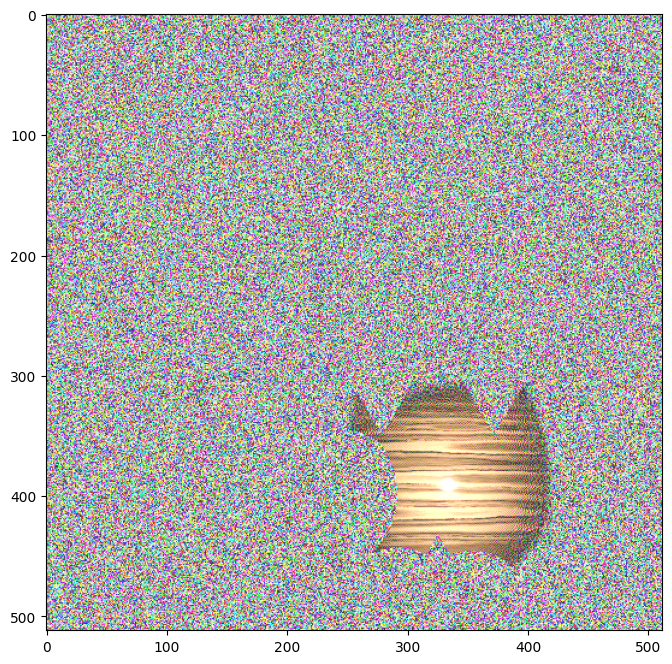

In [13]:
plt.figure(figsize=(8,8))
plt.imshow(x2.cpu()[2,...,0:3]**0.454)

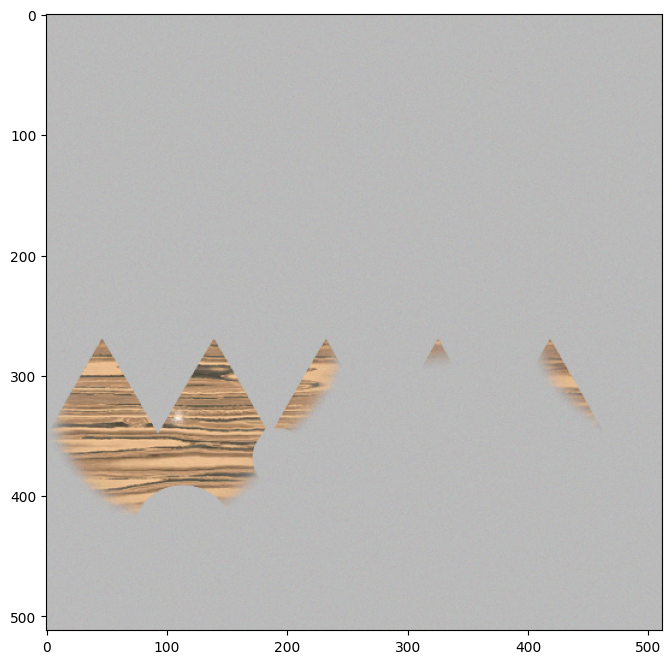

In [18]:
plt.figure(figsize=(8,8))
plt.imshow(x2.mean(axis=0).cpu()[...,0:3]**0.454)

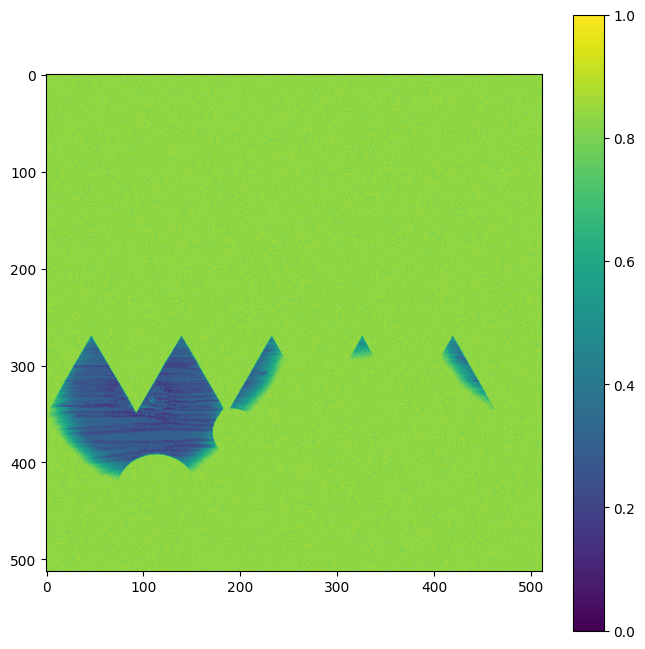

In [19]:
plt.figure(figsize=(8,8))
plt.imshow(x2.var(dim=0).sum(axis=-1).sqrt().cpu(), vmin=0, vmax=1)
plt.colorbar()

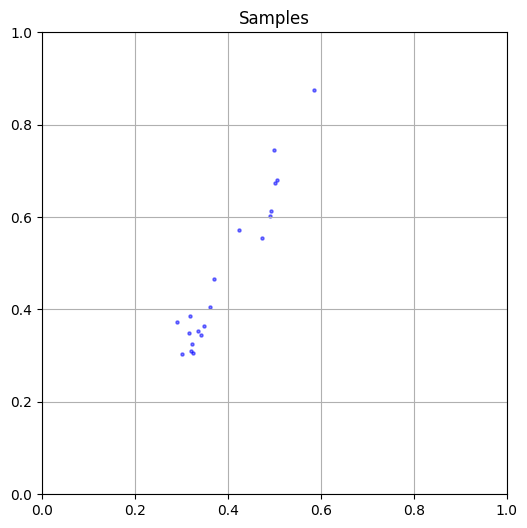

In [20]:
def plot_samples(samples, opacity=0.5, title='Samples', savefile=None):
    plt.figure(figsize=(6, 6))
    plt.scatter(samples[:, 0], samples[:, 1], c='blue', s=5, alpha=opacity)
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()
plot_samples(x2[:,340, 110,1::2].cpu())

In [ ]:
from scipy.interpolate import griddata
def plot_contour_from_samples(x, y, z, res=300):
    # Create a grid to interpolate onto
    grid_x = np.linspace(0, 1, res)
    grid_y = np.linspace(0, 1, res)
    grid_X, grid_Y = np.meshgrid(grid_x, grid_y)
    # Interpolate using griddata
    grid_Z = griddata((x, y), z, (grid_X, grid_Y), method='cubic')
    # grid_Z = griddata((x, y), z, (grid_X, grid_Y), method='cubic').clip(min=0, max=1)

    # Plotting
    plt.figure(figsize=(8, 6))
    contour = plt.contourf(grid_X, grid_Y, grid_Z, levels=41)
    # contour = plt.contourf(grid_X, grid_Y, grid_Z, levels=np.linspace(0,1,41))
    plt.colorbar(contour)
#     plt.scatter(x, y, color='k', s=1, alpha=0.5, label="Sample Points")
    plt.title("Distribution of parameter (visualized from Samples)")
    plt.xlabel("theta[0]: diffuse")
    plt.ylabel("theta[1]: roughness")
    plt.legend()
    plt.grid(True)
    plt.show()
    
def plot_conditional(x0, px, camera_ids):
    x = x0.clone()
    n = 4000
    sobol_engine = torch.quasirandom.SobolEngine(dimension=param_dim, scramble=True, seed=None)
    # samples = torch.rand((n, param_dim))
    samples = sobol_engine.draw(n)
    Us = []
    for theta in tqdm(samples):
        x[px][1] = theta[0]
        x[px][3] = theta[1]
        Us.append(U11(x, camera_ids=camera_ids)[0])
    Us = torch.tensor(Us)
    ps = (Us.min() - Us).exp()
    plot_contour_from_samples(samples[:,0], samples[:,1], Us - Us.min())

plot_conditional(x2.mean(0), (340, 110), camera_ids=3)

In [48]:
x2[1][340,110]

tensor([0.5513, 0.3415, 0.1563, 0.3449], device='cuda:0')

In [22]:
pip install scipy

  Using cached scipy-1.10.1-cp38-cp38-win_amd64.whl (42.2 MB)
Note: you may need to restart the kernel to use updated packages.
